# **Project Idea (Part A)**

### The safety of a car is one of the key considerations when evaluating and purchasing a car. This is especially important in the DMV area, where congested traffic and irratic driving behavior is normal and expected. With the negative perception of drivers in the DMV area, it's important to target the incident reports occurring in this region. For this reason, I've decided to evaluate the Montgomery County Crash Reporting Incident Dataset to identify the failure points of popular cars in the DMV region. By understanding the metrics in this dataset, we can obtain a different perspective on car safety tests by evaluating real crash data and not simulated crash tests. The main objective here is to identify the vunerabilities of popular car's in the Montgomery County region using the hundreds of thousands of datapoints collected by Montgomery County Police Department

# **Dataset Curation and Preprocessing (Part B)**

In [404]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import json
from scipy import stats
import seaborn as sns
from sklearn.model_selection import train_test_split

In [405]:
## Loading and Exploring the Data
col_datatypes = {
    "Report Number": str,
    "Local Case Number": str, 
    "Agency Name": str,
    "ACRS Report Type": str,
    "Crash Date/Time": str, 
    "Route Type": str, 
    "Road Name": str, 
    "Cross-Street Name": str, 
    "Off-Road Description": str, 
    "Municipality": str, 
    "Related Non-Motorist": str, 
    "Collision Type": str,
    "Weather": str,
    "Surface Condition": str,
    "Light": str,
    "Traffic Control": str,
    "Driver Substance Abuse": str,
    "Non-Motorist Substance Abuse": str,
    "Person ID": str,
    "Driver At Fault": str,
    "Injury Severity": str,
    "Circumstance": str,
    "Driver Distracted By": str,
    "Drivers License State": str,
    "Vehicle ID": str,
    "Vehicle Damage Extent": str,
    "Vehicle First Impact Location": str,
    "Vehicle Body Type": str,
    "Vehicle Movement": str,
    "Vehicle Going Dir": str,
    "Speed Limit": int,
    "Driverless Vehicle": str,
    "Parked Vehicle": str,
    "Vehicle Year": int,
    "Vehicle Make": str,
    "Vehicle Model": str,
    "Latitude": float,
    "Longitude": float,
    "Location": str
}

crash_df = pd.read_csv("Crash_Reporting_-_Drivers_Data.csv", dtype=col_datatypes)
print(f"Total Data Entries: {crash_df.shape[0]}")
print(f"Number of Features: {crash_df.shape[1]}")
print(f"Number of Numerical Features: {len(crash_df.select_dtypes(include=['int64', 'float64']).columns)}\n   \-> {list(crash_df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Number of Categorical Features: {len(crash_df.select_dtypes(include=['str']).columns)}\n   \-> {list(crash_df.select_dtypes(include=['str']).columns)}")
display(crash_df.head(3))

Total Data Entries: 210736
Number of Features: 39
Number of Numerical Features: 4
   \-> ['Speed Limit', 'Vehicle Year', 'Latitude', 'Longitude']
Number of Categorical Features: 35
   \-> ['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type', 'Crash Date/Time', 'Route Type', 'Road Name', 'Cross-Street Name', 'Off-Road Description', 'Municipality', 'Related Non-Motorist', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver Substance Abuse', 'Non-Motorist Substance Abuse', 'Person ID', 'Driver At Fault', 'Injury Severity', 'Circumstance', 'Driver Distracted By', 'Drivers License State', 'Vehicle ID', 'Vehicle Damage Extent', 'Vehicle First Impact Location', 'Vehicle Body Type', 'Vehicle Movement', 'Vehicle Going Dir', 'Driverless Vehicle', 'Parked Vehicle', 'Vehicle Make', 'Vehicle Model', 'Location']


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
0,MCP3126006X,250037402,MONTGOMERY,Injury Crash,08/21/2025 05:21:00 PM,Maryland (State) Route,NaN,NaN,NaN,NaN,...,Northbound,40,No,No,2013,KIA,SOUL,39.219796,-77.257416,"(39.219796, -77.25741635)"
1,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,NaN,NaN,NaN,...,Northbound,55,No,No,0,NaN,NaN,39.180181,-77.250657,"(39.18018079, -77.25065714)"
2,MCP296500BC,250033157,MONTGOMERY,Property Damage Crash,07/25/2025 11:55:00 AM,Bicycle Route,NaN,NEW HAMPSHIRE AVE (SB/L) NORBECK RD (WB/L) SPE...,NaN,NaN,...,Westbound,40,No,No,2023,LEXUS,RX,39.121219,-76.988905,"(39.12121898, -76.98890509)"


 #### From this data preview, we can see that this dataset has 39 features. Of these 39 features, 35 of them are categorical and the other 4 are numerical features. In addition, we have 210,736 entries in this dataset. With the preview alone, we can see that there exist many missing values that will mess up our data analysis and predictions. A good first step would be to handle these badly collected entries.

 ### Data Source:
 #### Montgomery County. (n.d.). Crash Reporting - Incidents data [Dataset].https://data.montgomerycountymd.gov/Public-Safety/Crash-Reporting-Incidents-Data/bhju-22kf/about_data

_______________________________________________________________________________________________________________________________________________________

# **Data Exploration and Summary Statistics (Part C)**

### **Check how unique values vs total values:**


In [406]:
total_entries = crash_df.shape[0]
unique_df = pd.DataFrame()
unique_df["Column Name"] = crash_df.columns
unique_df["Unique Values"] = unique_df["Column Name"].apply(lambda x: crash_df[x].nunique())
unique_df["Total Values"] = unique_df["Column Name"].apply(lambda x: total_entries - crash_df[x].isna().sum())
unique_df["Is Unique"] = unique_df["Unique Values"] == unique_df["Total Values"]
display(unique_df[:17].T)
display(unique_df[17:].T)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
Column Name,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,Related Non-Motorist,Collision Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse
Unique Values,118843,118729,10,3,115943,19,4789,7536,13978,20,28,28,23,21,16,33,20
Total Values,210736,210736,210736,210736,210736,190097,186385,170288,19597,19126,6879,210151,197380,186760,209291,181648,179416
Is Unique,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


,17,18,19,20,21,22,23,24,25,26,...,29,30,31,32,33,34,35,36,37,38
Column Name,Non-Motorist Substance Abuse,Person ID,Driver At Fault,Injury Severity,Circumstance,Driver Distracted By,Drivers License State,Vehicle ID,Vehicle Damage Extent,Vehicle First Impact Location,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
Unique Values,27,210736,3,10,814,24,81,210736,12,33,...,10,16,2,2,145,1964,7183,106074,108265,117985
Total Values,5733,210736,210736,208071,40985,207880,196386,210736,210420,210580,...,201211,210736,210736,209210,210736,209604,209562,210736,210736,210736
Is Unique,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


### **Let's Graph it!**

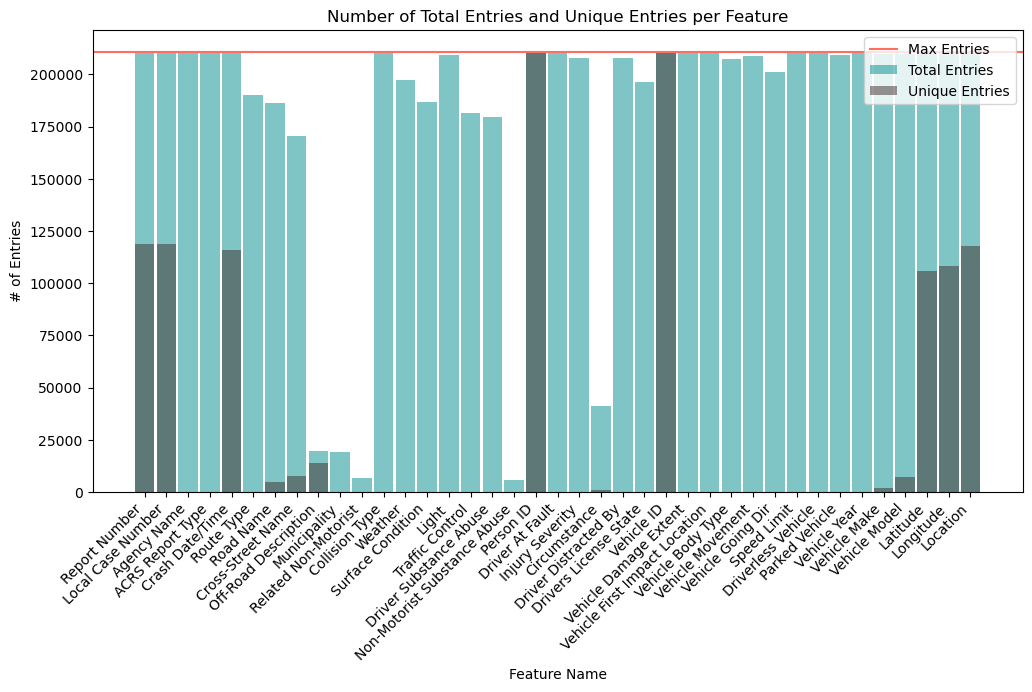

In [407]:
plt.figure(figsize=(12, 6))
plt.bar(unique_df["Column Name"], unique_df["Total Values"], alpha=0.5, width=0.9, label="Total Entries", color="#008C8C")
plt.bar(unique_df["Column Name"], unique_df["Unique Values"], alpha=0.5, width=0.9, label="Unique Entries", color="#3E2A2A")
plt.axhline(total_entries, color='#FF6F61', label='Max Entries')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Feature Name")
plt.ylabel("# of Entries")
plt.title("Number of Total Entries and Unique Entries per Feature")
plt.legend(loc="upper right")
plt.show()

_______________________________________________________________________________________________________________________________________________________

# **MISSING**

### **Understanding the missing values in our data**

In [408]:
na_dict = {}
print("==============[ N/A Statistics ]==============")
print(f"Out of {crash_df.shape[0]} entries, the following number of entries have no values for the columns]\n")
print(f"Total Entries: {crash_df.shape[0]}")
na_dict = crash_df.isna().sum().astype(int).to_dict()
sorted_na = dict(sorted(na_dict.items(), key=lambda x: x[1], reverse=True))
print(json.dumps(sorted_na, indent=2))

==============[ N/A Statistics ]==============
Out of 210736 entries, the following number of entries have no values for the columns]

Total Entries: 210736
{
  "Non-Motorist Substance Abuse": 205003,
  "Related Non-Motorist": 203857,
  "Municipality": 191610,
  "Off-Road Description": 191139,
  "Circumstance": 169751,
  "Cross-Street Name": 40448,
  "Driver Substance Abuse": 31320,
  "Traffic Control": 29088,
  "Road Name": 24351,
  "Surface Condition": 23976,
  "Route Type": 20639,
  "Drivers License State": 14350,
  "Weather": 13356,
  "Vehicle Going Dir": 9525,
  "Vehicle Body Type": 3212,
  "Driver Distracted By": 2856,
  "Injury Severity": 2665,
  "Vehicle Movement": 1679,
  "Parked Vehicle": 1526,
  "Light": 1445,
  "Vehicle Model": 1174,
  "Vehicle Make": 1132,
  "Collision Type": 585,
  "Vehicle Damage Extent": 316,
  "Vehicle First Impact Location": 156,
  "Report Number": 0,
  "Local Case Number": 0,
  "Agency Name": 0,
  "ACRS Report Type": 0,
  "Crash Date/Time": 0,
  "Per

#### From the previous results, we can see that the columns `"Non-Motorist Substance Abuse"`, `"Related Non-Motorists"`, `"Municipality"`, `"Off-Road Description"`, `"Circumstance"`, `"Cross-Street Name"`, `"Driver Substance Abuse"`, and `"Traffic Control"` have over 25,000 missing values in the dataset. We can conclude that these columns should be reconsidered in our EDA as their omission would allow us to consider more datapoints. 

### **Let's remove these features!**

In [409]:
sparse_cols = []
for key in sorted_na:
    if sorted_na[key] > 25000:
        sparse_cols.append(key)
if sparse_cols[0] in crash_df.columns:
    crash_df = crash_df.drop(columns=sparse_cols)
print(f"Number of features: {crash_df.shape[1]-2}")

Number of features: 29


### **Now that we've filtered the features, lets drop any entries with N/A values**

In [410]:
crash_df = crash_df.dropna()
print(f"Number of features: {crash_df.shape[1]-2} and Number of entries: {crash_df.shape[0]}")
display(crash_df.head(3))

Number of features: 29 and Number of entries: 152393


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,Northbound,25,No,No,2016,MAZDA,CX-5,39.092734,-77.076470,"(39.09273383, -77.07647)"
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,Eastbound,35,No,No,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,"(39.15322038, -77.06701504)"
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,Southbound,40,No,No,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,"(39.17693504, -77.27019937)"


_______________________________________________________________________________________________________________________________________________________

# **OUTLIERS**

### After analyzing the number of missing values in our datatset, we should try to eliminate entries that contain outliers in any of our numerical categories. Taking a look at these categories, we can see that speed limit cannot contain outliers because its a numerical representation of categorical data and our position data cannot contain outliers because they're valid longitude and latitude values within Maryland. This leaves us with `Vehicle Year` to eliminate outliers from. 
  
## Let's start with that:

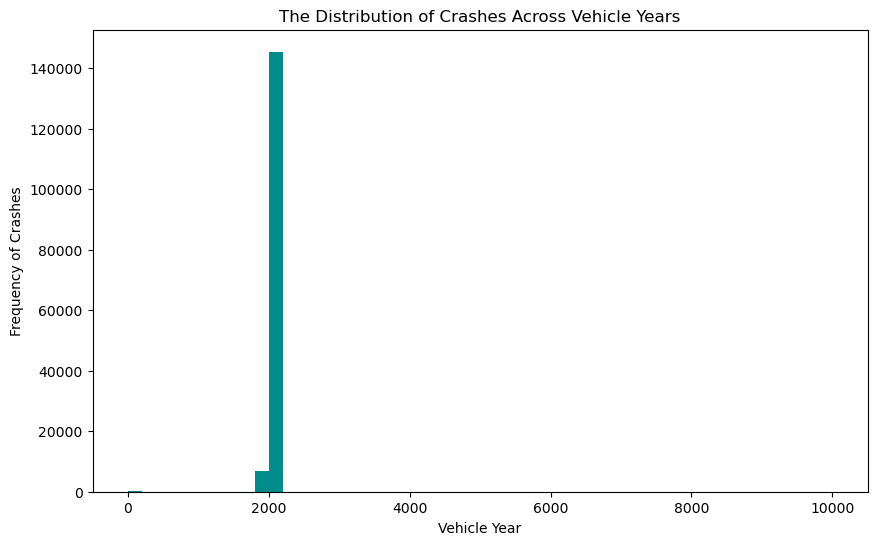

In [411]:
## Plot the current distribution of datapoints
plt.figure(figsize=(10, 6))
plt.hist(crash_df["Vehicle Year"], bins=50, color="#008C8C")
plt.xlabel("Vehicle Year")
plt.ylabel("Frequency of Crashes")
plt.title("The Distribution of Crashes Across Vehicle Years")
plt.show()

### Hmm... Something seems to be wrong with the distribution of values for `Vehicle Years`. The first problematic observation that can be made is the hump in the 0 bin. This, for obvious reasons, doesn't make sense for vehicle car years. In addition, we can see that the graph has auto-distributed across a range of `(0,10000)`. This tells us that there must be some low-frequency outliers towards the 10,000 mark that's spreading the graph thin.

### **Let's explore this in further detail:**

In [412]:
desc_stats = crash_df["Vehicle Year"].describe()
IQR = desc_stats["75%"] - desc_stats["25%"]
lower_bound = int(desc_stats["25%"] - (1.5*IQR))
upper_bound = int(desc_stats["75%"] + (1.5*IQR))
print(f"IQR:{IQR}")
print(f"We declare points outside of the range {lower_bound} <= x <= {upper_bound} an outlier")
print("This makes the following unique values outliers:")
vehicle_years = crash_df[(crash_df["Vehicle Year"]>upper_bound) | (crash_df["Vehicle Year"]<lower_bound)]["Vehicle Year"].unique()
print(vehicle_years)

IQR:9.0
We declare points outside of the range 1993 <= x <= 2029 an outlier
This makes the following unique values outliers:
[1111 1992 1990 1988 1987 1977 9999 1989 1991 1984    0 1900 1981 2915
 1983 1966   99 2033  200 1967    3 1975 1980 1978 1969  201 2918  215
 1986 2996 1965 1982 2917 2103 2040 1985 1968 1972 1960 1970   15 1938
 1979 2991 1949 1901 2997  202 1976   97 1971 3013 2914 5005 2911 2201
 1140 1961 1005 1947 2099 1014 2100 1955 2208 1974 2200 1930    8 1963
 2048 2104 1015  198 2919 2055 3003   13 8008 2204 3863 2912    2 1008
   14 1959 1025 2998    4 1234 9000 3012 2109 1957]


### Looking at the data, we can compute an `IQR` of 10 (2016 - 2006). This gives us a `lower_bound` and `upper_bound` of 1991 and 2031 respectively. When we calculate the possible outlier points, however, we allow implausible values to persist in our data. To ellaborate, an `upper_bound` of 2031 doesn't make sense to describe this feature, since the maximum possible value for `Vehicle Year` is 2027. For these reasons we might want to implement a manual cap for the upper bounds and keep the lower bounds the same.

### **How about we implement a hardcap for the upperbounds?**

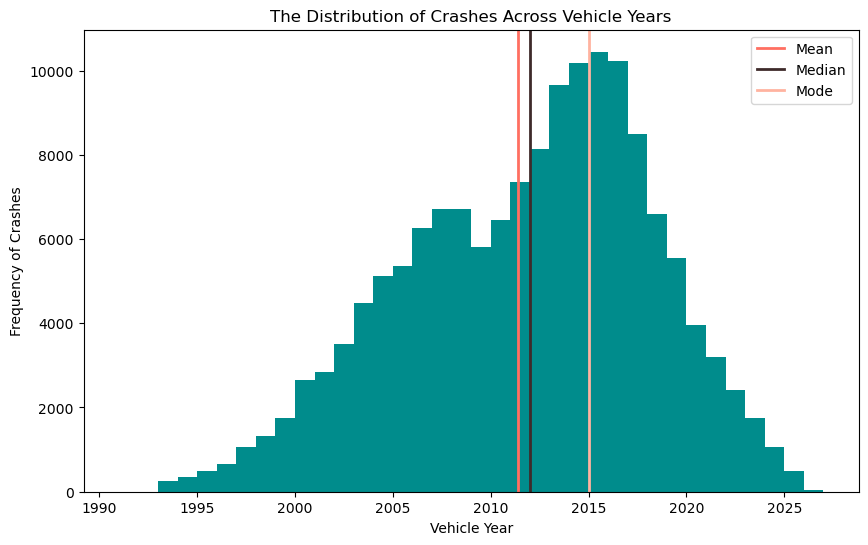

In [413]:
filtered_values = crash_df[(crash_df["Vehicle Year"]<=2027) & (crash_df["Vehicle Year"]>=lower_bound)]["Vehicle Year"]
#print(sorted(filtered_values.unique()))
plt.figure(figsize=(10, 6))
plt.hist(filtered_values, bins=36, range=(1991,2027), color="#008C8C")
plt.axvline(filtered_values.mean(), label="Mean", color="#FF6F61", lw=2.0)
plt.axvline(filtered_values.median(), label="Median", color="#3E2A2A", lw=2.0)
plt.axvline(filtered_values.mode()[0], label="Mode", color="#FFB3A0", lw=2.0)
plt.xlabel("Vehicle Year")
plt.ylabel("Frequency of Crashes")
plt.title("The Distribution of Crashes Across Vehicle Years")
plt.legend()
plt.show()

### With this showing promising results, lets drop any rows that fall outsides of the lower, upper range

In [414]:
out_of_bounds_idx = crash_df[(crash_df["Vehicle Year"]>2027) | (crash_df["Vehicle Year"]<lower_bound)].index
crash_df.drop(index=out_of_bounds_idx,axis=0,inplace=True)
print(f"Entries Left: {crash_df.shape[0]}, Entries Deleted: {total_entries-crash_df.shape[0]}")

Entries Left: 151366, Entries Deleted: 59370


### We can effectively select our lower and upper bounds for outliers by using a modified version of `IQR` outlier selection. We choose to use the lower bound from `IQR` because it provides an accurate representation of the data. For the upper bounds, however, we choose to select the maximum possible valid year for `Vehicle Years`. This allows us to pick the best possible range for outliers.
  
### In addition, we can conclude that the distribution of `Vehicle Years` is left-skewed since the **Mode > Median > Mean**. Furthermore, we can see that the data is bimodal with peaks at **2008** and **2016**

_______________________________________________________________________________________________________________________________________________________

# **CONVERTING DATATYPES**

#### Some of the datatypes in our features are incorrect, so lets alter them to make them more apporiate for analysis and feature engineering.

#### The first datatype that we should analyze is the `Crash Date/Time`. Currently `Crash Date/Time` is of type string, we should convert this to a `datetime.datetime` object

In [415]:
if "Crash Datetime" not in crash_df.columns:
    crash_df["Crash Datetime"] = crash_df["Crash Date/Time"].apply(lambda x: pd.to_datetime(x))
print(crash_df["Crash Date/Time"].dtype)
display(crash_df.head(3))

str


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location,Crash Datetime
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,25,No,No,2016,MAZDA,CX-5,39.092734,-77.076470,"(39.09273383, -77.07647)",2025-08-19 09:50:00
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,35,No,No,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,"(39.15322038, -77.06701504)",2025-08-04 15:47:00
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,40,No,No,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,"(39.17693504, -77.27019937)",2025-08-19 20:35:00


#### The next columns we should look at are the `Driverless Vehicle` column and the `Parked Vehicle` column. Since both of these columns are only yes or no values, we should turn them into a integer representation of boolean values (0 and 1)

In [416]:
if crash_df["Driverless Vehicle"].dtype != float:
    crash_df["Driverless Vehicle"] = crash_df["Driverless Vehicle"].map({"No": 0,"Yes": 1})
if crash_df["Parked Vehicle"].dtype != float:
    crash_df["Parked Vehicle"] = crash_df["Parked Vehicle"].map({"No": 0,"Yes": 1})
if crash_df["Driver At Fault"].dtype != float:
    crash_df["Driver At Fault"] = crash_df["Driver At Fault"].map({"No": 0,"Yes": 1, "Unknown": np.nan})

display(crash_df[["Driverless Vehicle", "Parked Vehicle", "Driver At Fault"]])

,Driverless Vehicle,Parked Vehicle,Driver At Fault
5,0.0,0,0.0
9,0.0,0,1.0
11,0.0,0,0.0
13,0.0,0,0.0
14,0.0,0,1.0
...,...,...,...
210729,0.0,0,0.0
210730,0.0,0,0.0
210731,0.0,0,1.0
210733,0.0,0,1.0


#### Data in the `Vehicle First Impact Location`, `Vehicle Movement`, and `Vehicle Going Dir` columns needs to be standardized to be all uppercase and without spaces. Additionally any category with under 1000 entries should be eliminated.

In [452]:
crash_df["Vehicle First Impact Location"] = crash_df["Vehicle First Impact Location"].str.upper().str.replace(" ", "")
crash_df["Vehicle Movement"] = crash_df["Vehicle Movement"].str.upper()
crash_df["Vehicle Going Dir"] = crash_df["Vehicle Going Dir"].str.upper().str.replace("BOUND", "")
crash_df["Light"] = crash_df["Light"].str.upper()
crash_df["Vehicle Damage Extent"] = crash_df["Vehicle Damage Extent"].str.upper()
"Vehicle Damage Extent"

movement_freq = crash_df["Vehicle Movement"].value_counts()
impact_freq = crash_df["Vehicle First Impact Location"].value_counts()
dir_freq =  crash_df["Vehicle Going Dir"].value_counts()
light_freq = crash_df["Light"].value_counts()
damage_freq = crash_df["Vehicle Damage Extent"].value_counts()

important_movement = movement_freq[movement_freq >= 1000]
important_impact = impact_freq[impact_freq >= 1000]
important_dir = dir_freq[dir_freq >= 1000]
important_light = light_freq[light_freq >= 1000]
important_damage = damage_freq[damage_freq >= 1000]

crash_df = crash_df[crash_df["Vehicle First Impact Location"].isin(important_impact.index)]
crash_df = crash_df[crash_df["Vehicle Movement"].isin(important_movement.index)]
crash_df = crash_df[crash_df["Vehicle Going Dir"].isin(important_dir.index)]
crash_df = crash_df[crash_df["Light"].isin(important_light.index)]
crash_df = crash_df[crash_df["Vehicle Damage Extent"].isin(important_damage.index)]

display(crash_df[["Vehicle First Impact Location", "Vehicle Movement", "Vehicle Going Dir", "Light", "Vehicle Damage Extent"]].head(5))

,Vehicle First Impact Location,Vehicle Movement,Vehicle Going Dir,Light,Vehicle Damage Extent
5,TWELVEOCLOCK,MOVING CONSTANT SPEED,NORTH,DAYLIGHT,SUPERFICIAL
9,TWELVEOCLOCK,ACCELERATING,EAST,DAYLIGHT,SUPERFICIAL
11,SEVENOCLOCK,STOPPED IN TRAFFIC,SOUTH,DARK - LIGHTED,SUPERFICIAL
13,THREEOCLOCK,MOVING CONSTANT SPEED,WEST,DARK - LIGHTED,FUNCTIONAL
14,TWOOCLOCK,MOVING CONSTANT SPEED,EAST,DAYLIGHT,DISABLING


#### Lastly the datatype for our `Location` column looks a little bit odd. When looking at this column, we can see that each of the values is a tuple of the `Latitude` and `Longitude` columns. This indicates that we might be better off removing this column.


In [418]:
if "Location" in crash_df.columns:
    crash_df = crash_df.drop(columns=["Location"])
display(crash_df.head(3))

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Crash Datetime
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,NORTH,25,0.0,0,2016,MAZDA,CX-5,39.092734,-77.076470,2025-08-19 09:50:00
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,EAST,35,0.0,0,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,2025-08-04 15:47:00
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,SOUTH,40,0.0,0,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,2025-08-19 20:35:00


# **FEATURE ENGINEERING**

#### In order to be able to make more accurate predictions, we should generate our own features to represent complex data patterns that might be present in our data. This could be non-linear patterns such as polynomial patterns or circular patterns. Lets take a look at our data to see what types of complex patterns we can computer for our model

#### One of the complicated numerical features we have is the `Crash Date/Time` column, we might want to extract some key metrics from this data. One of the things we can extract is the time of day, this will allow us to grab insights on whether the target variable is variant to alertness by drivers during certain hours and visible sunlight during certain hours.

In [419]:
crash_df["Season"]      = crash_df["Crash Datetime"].apply(lambda x: "Winter" if (x.month == 12 or x.month <= 2) else ("Spring" if (x.month > 2 and x.month <= 5) else ("Summer" if (x.month > 5 and x.month <= 8) else "Fall")))
crash_df["Time of Day"] = crash_df["Crash Datetime"].apply(lambda x: "Morning" if (x.hour < 12 and x.hour >= 5) else ("Afternoon" if (x.hour < 17 and x.hour >= 12) else ("Evening" if (x.hour < 21 and x.hour >= 17) else "Night")))
display(crash_df.head(3))

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Crash Datetime,Season,Time of Day
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,0.0,0,2016,MAZDA,CX-5,39.092734,-77.076470,2025-08-19 09:50:00,Summer,Morning
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,0.0,0,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,2025-08-04 15:47:00,Summer,Afternoon
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,0.0,0,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,2025-08-19 20:35:00,Summer,Evening


Let's test the time of day column to see if the frequency of crashes is dependent on the `Time of Day`

,Morning,Afternoon,Evening,Night
0,44395,47588,33678,17710


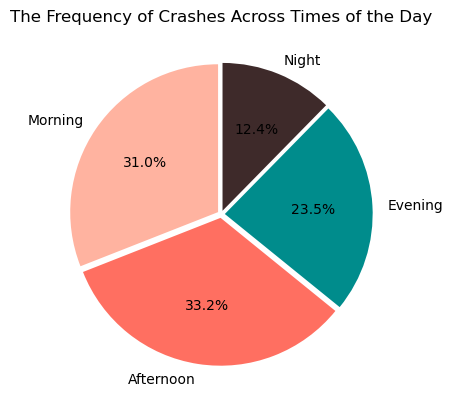

In [420]:
time_freq = pd.DataFrame(columns=["Morning", "Afternoon", "Evening", "Night"])
for time in crash_df["Time of Day"].unique():
    time_freq.loc[0, time] = crash_df[crash_df["Time of Day"] == time].shape[0]
    
display(time_freq)
plt.pie(time_freq.loc[0,:], explode=[0.025,0.025,0.025,0.025], labels=["Morning", "Afternoon", "Evening", "Night"], startangle=90, autopct="%1.1f%%", colors=["#FFB3A0", "#FF6F61", "#008C8C", "#3E2A2A"])
plt.title("The Frequency of Crashes Across Times of the Day")
plt.show()

After examining this graph, we have reason to believe there is a connection between crashes and times of the day. To test this hypothesis lets use the chi-squared test: 
   
Using the significance level of $\alpha = 0.05$
- HO: The frequency of crashes is equally distributed across `Time of Day`

- HA: The frequency of crashes is not equally distributed across `Time of Day`

In [421]:
chisquare_res = stats.chisquare((time_freq.loc[0,:].astype(float).values))

print(f"Chi-square Statistic: {chisquare_res.statistic}")
print(f"p-value: {chisquare_res.pvalue}")

Chi-square Statistic: 15193.439196211228
p-value: 0.0


#### **Conclusion**
#### Since this p-value is less than the significance level **(0.0 < 0.05)**, we can reject the Null Hypothesis(**HO**) and conclude that the frequency of crashes cannot be equally distributed across `Time of Day`

_______________________________________________________________________________________________________________________________________________________

#### Another feature that we can extract from the data is the Area of the Crash. Based on the speed limit, we can derive where the crash took place. We use a simple heuristic to determine where the crash takes place. If x<=15 its in an alley, if x<=35 its a residential, if x<=55 its a highway, otherwise its an interstate. This allows us to bin the numerical data into meaningful categories that can be used for analysis later on.

In [422]:
crash_df["Crash Area"] = crash_df["Speed Limit"].apply(lambda x: "Alleys" if (x <= 15) else ("Residential" if (x <= 35) else ("Highway" if (x <= 55) else ("Interstate"))))
display(crash_df.head(3))

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Crash Datetime,Season,Time of Day,Crash Area
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,0,2016,MAZDA,CX-5,39.092734,-77.076470,2025-08-19 09:50:00,Summer,Morning,Residential
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,0,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,2025-08-04 15:47:00,Summer,Afternoon,Residential
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,0,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,2025-08-19 20:35:00,Summer,Evening,Highway


## **Combined Target Variable**

#### Finally we also need to create our combined target variable. In this study we want to predict the make and model of the cars involved in the crashes. We should create a new target variable that combines these two columns into one.

In [423]:
crash_df["MakeModel"] = crash_df["Vehicle Make"] + "_" + crash_df["Vehicle Model"]
print(crash_df["MakeModel"].nunique())
display(crash_df.head(3))

11745


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Collision Type,Weather,Surface Condition,...,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Crash Datetime,Season,Time of Day,Crash Area,MakeModel
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,Single Vehicle,Rain,Wet,...,2016,MAZDA,CX-5,39.092734,-77.076470,2025-08-19 09:50:00,Summer,Morning,Residential,MAZDA_CX-5
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),Front to Rear,Clear,Dry,...,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,2025-08-04 15:47:00,Summer,Afternoon,Residential,FORD_TRANSIT CONNECT
11,MCP3381002W,250037120,MONTGOMERY,Property Damage Crash,08/19/2025 08:35:00 PM,County Route,WISTERIA DR,Front to Rear,Clear,Dry,...,2016,GILLIG,LOW FLOOR BUS,39.176935,-77.270199,2025-08-19 20:35:00,Summer,Evening,Highway,GILLIG_LOW FLOOR BUS


### **WOAH!** 
#### The number of classes in our target variable suddenly jumped to over 10,000. This clearly won't work for our analysis since we won't have a sufficient enough model and we won't have sufficient enough data. We should take some steps to limit the number of target classes. 

#### How about we cut out the bottom 5% of data points in frequency, this will allow us to get rid of the data points with barely any samples in our data. Cutting out the bottom 2.5% of data points will also improve our prediction capabilities since each class will have a proper sample size within our data. 

95


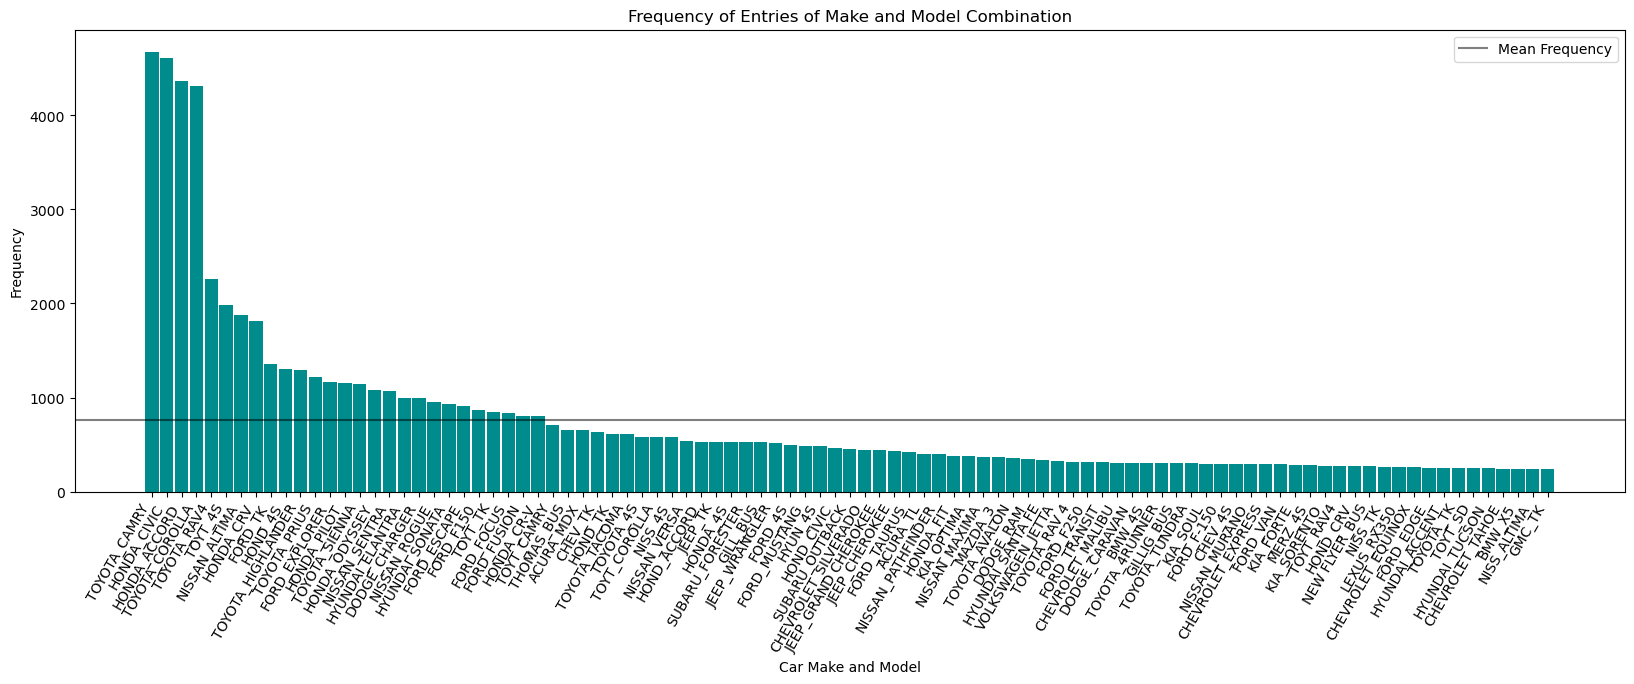

In [424]:
makemode_freq = crash_df["MakeModel"].value_counts()
filtered_makemodels = makemode_freq[makemode_freq.values > (0.05*makemode_freq.values[0])]
print(len(filtered_makemodels))
plt.figure(figsize=(20,6))
plt.bar(filtered_makemodels.index, filtered_makemodels.values, width=.9, color="#008C8C")
plt.xticks(rotation=60, ha='right')
plt.xlabel("Car Make and Model")
plt.ylabel("Frequency")
plt.title("Frequency of Entries of Make and Model Combination")
plt.axhline((filtered_makemodels.values.mean()), label="Mean Frequency", color='black', alpha = 0.5)
plt.legend()
plt.show()

#### After finding the distribution of the remaining car make and models, we should look at number of remaining datapoints to ensure they have not dipped below a reasonable amount.

In [425]:
print(f"The filtered dataset has {crash_df.shape[0]} entries and {crash_df.shape[1]} columns")
print(f"Column Names: {list(crash_df.columns)}")

The filtered dataset has 143371 entries and 35 columns
Column Names: ['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type', 'Crash Date/Time', 'Route Type', 'Road Name', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Person ID', 'Driver At Fault', 'Injury Severity', 'Driver Distracted By', 'Drivers License State', 'Vehicle ID', 'Vehicle Damage Extent', 'Vehicle First Impact Location', 'Vehicle Body Type', 'Vehicle Movement', 'Vehicle Going Dir', 'Speed Limit', 'Driverless Vehicle', 'Parked Vehicle', 'Vehicle Year', 'Vehicle Make', 'Vehicle Model', 'Latitude', 'Longitude', 'Crash Datetime', 'Season', 'Time of Day', 'Crash Area', 'MakeModel']


_______________________________________________________________________________________________________________________________________________________

# **FEATURE SELECTION**

### In order to explore the relationships between our categorical features, we might opt to use a correlation heatmap. This type of graph can display the effective relationships between variables, which variables might be redundant, and allows us to pick the most useful features for future exploration.

In [426]:
# Faded because too high cardinality: 'Report Number', 'Local Case Number', 'Road Name', 'Person ID', 'Vehicle ID'
# Faded because not enough cardinality: 'Drivers License State', 'Driverless Vehicle', 'Parked Vehicle', 
# Faded because its numerical: 'Vehicle Year', 'Latitude', 'Longitude',
# Faded because its target variable:  'Vehicle Make', 'Vehicle Model',

cat_cols = ["Agency Name", "ACRS Report Type", "Time of Day", "Route Type", "Collision Type", "Vehicle First Impact Location", "Vehicle Movement", "Vehicle Going Dir", "Weather", "Surface Condition", "Light", "Driver At Fault", "Injury Severity", "Driver Distracted By", "Vehicle Damage Extent", "Vehicle Body Type", "Crash Area", "Season"]
cat_df = crash_df[cat_cols].dropna()
heat_map = pd.DataFrame(index=cat_cols, columns=cat_cols)

for x in cat_cols:
    for y in cat_cols:
        contingency_table = stats.contingency.crosstab(cat_df[x].astype(str), cat_df[y].astype(str))
        #display(contingency_table.count)
        heat_map.loc[x,y] = stats.contingency.association(contingency_table.count, method='cramer')
#display(heat_map)

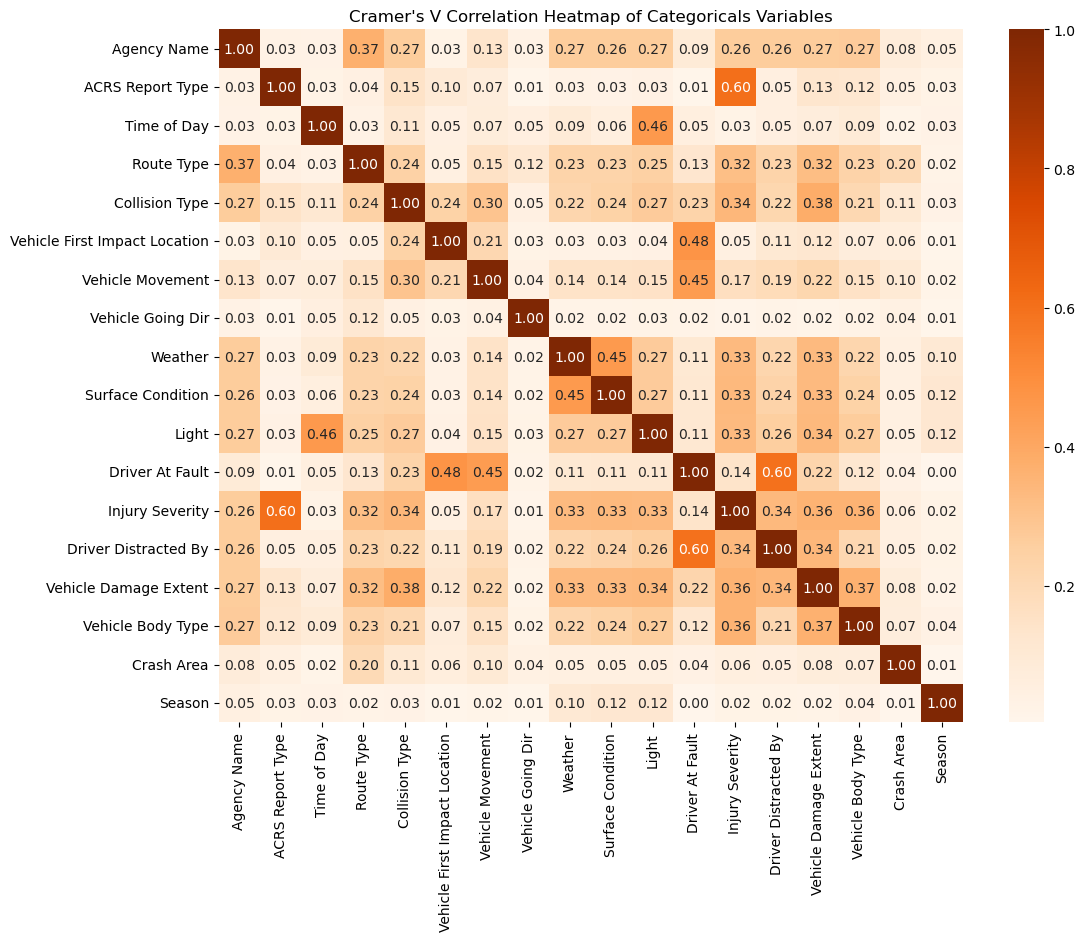

In [427]:
plt.figure(figsize=(12, 9))
sns.heatmap(heat_map.astype(float), annot=True, cmap='Oranges', fmt='.2f')
plt.title("Cramer's V Correlation Heatmap of Categoricals Variables")
plt
plt.show()

.

### **Next lets take a look at the correlation between each categorical feature and the target variable**

In [428]:
cat_target_df = crash_df[(cat_cols+["MakeModel"])]
cat_target_df = cat_target_df.dropna()
heat_map_target = pd.DataFrame(index=(cat_cols+["MakeModel"]), columns=(cat_cols+["MakeModel"]))
for x in (cat_cols+["MakeModel"]):
    for y in (cat_cols+["MakeModel"]):
        contingency_table = stats.contingency.crosstab(cat_target_df[x].astype(str), cat_target_df[y].astype(str))
        heat_map.loc[x,"MakeModel"] = stats.contingency.association(contingency_table.count, method='cramer')

In [429]:
rankings_dict = {}
for row_idx in range(len(heat_map.columns)):
    for col_idx in range(len(heat_map.columns)):
        if col_idx >= row_idx:
            continue
        rankings_dict[(heat_map.columns[row_idx], heat_map.columns[col_idx])] = heat_map.iloc[row_idx, col_idx]
sorted_dict = dict(sorted(rankings_dict.items(), key=lambda x: x[1], reverse=True))

for key in sorted_dict:
    if sorted_dict[key] >= 0.35:
        print(f" Columns {key[0]} and {key[1]} have a Cramer's coefficient of {sorted_dict[key]}")

 Columns Injury Severity and ACRS Report Type have a Cramer's coefficient of 0.604311340760007
 Columns Driver Distracted By and Driver At Fault have a Cramer's coefficient of 0.5954094587621245
 Columns Driver At Fault and Vehicle First Impact Location have a Cramer's coefficient of 0.4764168281050574
 Columns Light and Time of Day have a Cramer's coefficient of 0.458199659511897
 Columns Surface Condition and Weather have a Cramer's coefficient of 0.4538959956353231
 Columns Driver At Fault and Vehicle Movement have a Cramer's coefficient of 0.44665632076504147
 Columns Vehicle Damage Extent and Collision Type have a Cramer's coefficient of 0.381804624005869
 Columns Route Type and Agency Name have a Cramer's coefficient of 0.37203533272438105
 Columns Vehicle Body Type and Vehicle Damage Extent have a Cramer's coefficient of 0.36805287439463713
 Columns Vehicle Damage Extent and Injury Severity have a Cramer's coefficient of 0.36036335437069233
 Columns Vehicle Body Type and Injury 

### **Conclusion**  
#### From this heat map and ranking of information we can conclude which categorical features would be correlated. From our findings, we can conclude from the `(Injury Severity, ACRS Report Type)`, `(Driver Distracted By, Driver At Fault)`, `(Driver At Fault, Vehicle First Impact Location)`, `(Light, Time of Day)`, `(Surface Condition, Weather)`, `(Driver At Fault, Vehicle Movement)`, `(Vehicle Damage Extent, Collision Type)`, `(Route Type, Agency Name)`, `(Vehicle Body Type, Vehicle Damage Extent)`, `(Vehicle Damage Extent, Injury Severity)`, `(Vehicle Body Type, Injury Severity)` are strongly linked as they have a Cramer's V > 0.35. 
####  **It's important to note** that we cannot conlude that these variables are positively or negatively correlated, only that knowing one can be a meaningful way of predicting the other. 
  

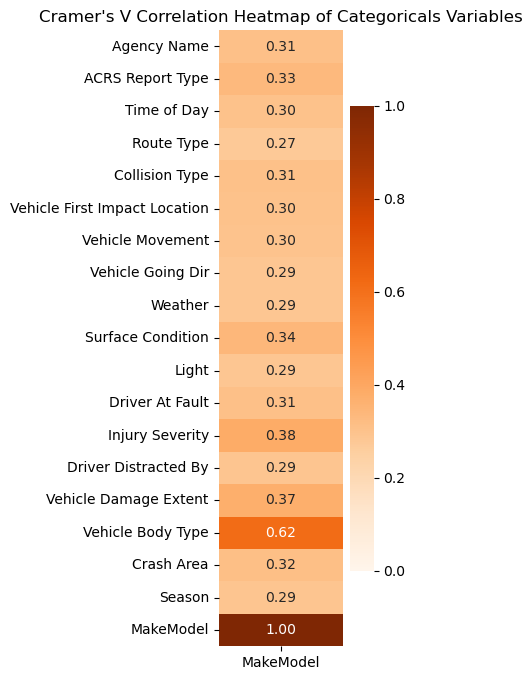

In [430]:
plt.figure(figsize=(2, 8))
iso_heatmap = pd.DataFrame(heat_map.loc[:,"MakeModel"])
sns.heatmap(iso_heatmap.astype(float), annot=True, cmap='Oranges', fmt='.2f', vmin=0, vmax=1)
plt.title("Cramer's V Correlation Heatmap of Categoricals Variables")
plt
plt.show()

In [431]:
rankings_dict = {}
for row_idx in range(len(iso_heatmap)):
    rankings_dict[(iso_heatmap.index[row_idx], iso_heatmap.columns[0])] = iso_heatmap.iloc[row_idx, 0]
sorted_dict = dict(sorted(rankings_dict.items(), key=lambda x: x[1], reverse=True))

for key in sorted_dict:
    if sorted_dict[key] >= 0.35 and key[0] != key[1]:
        print(f" Columns {key[0]} and {key[1]} have a Cramer's coefficient of {sorted_dict[key]}")

 Columns Vehicle Body Type and MakeModel have a Cramer's coefficient of 0.6170283188994904
 Columns Injury Severity and MakeModel have a Cramer's coefficient of 0.38349863184863636
 Columns Vehicle Damage Extent and MakeModel have a Cramer's coefficient of 0.372515736307569


### **Conclusion**  

#### From this heatmap of our categorical data's association with the categorical data, the following pairs of categorical data are highly associated `(Vehicle Body Type, MakeModel)`, `(Injury Severity, MakeModel)`, `(Vehicle Damage Extent, MakeModel)` as they have a Cramer's V constant > 0.35

####  **It's important to note** that we cannot conlude that these variables are positively or negatively correlated, only that knowing one can be a meaningful way of predicting the other.

# **ML Algorithm Design/Development (Part D)**

In [455]:
all_features = ["Agency Name", "ACRS Report Type", "Time of Day", "Route Type", "Collision Type", "Vehicle First Impact Location", "Vehicle Movement", "Vehicle Going Dir", "Weather", "Surface Condition", "Light", "Driver At Fault", "Injury Severity", "Driver Distracted By", "Vehicle Damage Extent", "Vehicle Body Type", "Crash Area", "Season", "Vehicle Year", "Latitude", "Longitude"]
print(len(all_features))
target = ["MakeModel"]
cat_ord_feat = ["Time of Day", "Light", "Season", "Vehicle Damage Extent", "Crash Area"]
# Time of Day: Morning, Afternoon, Evening, Night
# Light: DAYLIGHT, DAWN, DUSK, DARK - LIGHTED, DARK LIGHTS ON, DARK NO LIGHTS
# Season: Winter, Spring, Summer, Fall
# Vehicle Damage Extent: NO DAMAGE, SUPERFICIAL, FUNCTIONAL, DISABLING, DESTROYED
# Crash Area: Alleys, Residential, Highway, Interstate
cat_feat = ["Agency Name", "ACRS Report Type", "Route Type", "Collision Type", "Vehicle First Impact Location", "Vehicle Movement", "Vehicle Going Dir", "Weather", "Surface Condition", "Injury Severity", "Driver Distracted By", "Vehicle Body Type"]
num_feat = ["Vehicle Year", "Latitude", "Longitude", "Driver At Fault"] 


21


# **ML Algorithm Training and Test Data Analysis (Part E)**

# **Visualization, Result Analysis, Conclusion (Part F)**

# **Final Tutorial Report Creation (Part G)**

# **Additional (Part H)**